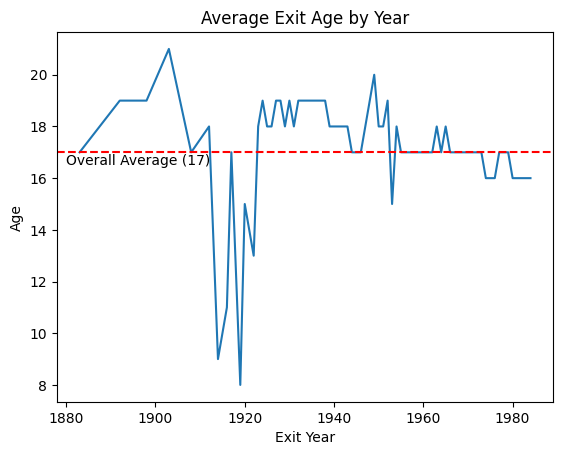

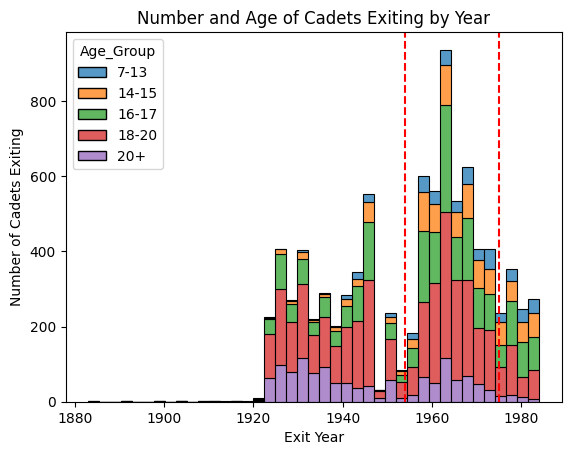

In [27]:
'''Analysis program for the Agusta Military Academy data cleaning project'''
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned CSV as a DataFrame
df = pd.read_csv('alumni_clean.csv')

# Dataframe of average age per year
df_avg_age = df.groupby('Exit_Year')['Age_at_Exit'].mean()
df_avg_age = df_avg_age.reset_index()
df_avg_age = df_avg_age.rename(columns={"Age_at_Exit":"Avg_Exit_Age"})
df_avg_age['Avg_Exit_Age'] = round(df_avg_age['Avg_Exit_Age'])

# Plot of average exit age by year
ax1 = sns.lineplot(df_avg_age,x='Exit_Year',y='Avg_Exit_Age')
ax1.set_title("Average Exit Age by Year")
ax1.set_xlabel("Exit Year")
ax1.set_ylabel("Age")

# Mark and label the overall average exit age for the full dataset
avg_age = round(df['Age_at_Exit'].mean())
ax1.axhline(y=avg_age, xmin=0, xmax=1,color='r',linestyle='--')
ax1.text(1880,16.5,f'Overall Average ({avg_age})')

# Save and show
plt.savefig('Avg_Exit_By_Year')
plt.show()

# Plotting number of cadets by exit year

# Bins and labels for age categories
# 7-13, 14-15, 16-17, 18-20, 20+
agebins = [0, 13, 15, 17, 19, float('inf')]
agelabels = ['7-13', '14-15','16-17','18-20','20+']

age_categories = pd.cut(df['Age_at_Exit'], bins=agebins, labels=agelabels)
df['Age_Group'] = age_categories # Set the age groups as a new col in the dataframe

# Setup plot and show it
ax2 = sns.histplot(df,x='Exit_Year',hue='Age_Group',multiple='stack')
ax2.set_title("Number and Age of Cadets Exiting by Year")
ax2.set_xlabel("Exit Year")
ax2.set_ylabel("Number of Cadets Exiting")
plt.savefig('Exit_By_Year')
ax2.axvline(x=1954,color='red',linestyle='--')
ax2.axvline(x=1975,color='red',linestyle='--')


# Save and show
plt.savefig('Exit_By_Year_Vietnam')
plt.show()